<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/AstroEstadistica/PARCIAL2_ESTADISTIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parcial 2 Astroetadistica: parte práctica: Tratamiento de datos del movimiento aparente del sola**


cc. 1002587562

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import stats
from scipy.optimize import curve_fit
from google.colab import files

%matplotlib inline
plt.style.use('seaborn-v0_8-dark-palette')

In [ ]:
# carga archivos (datos_hora_militar.zip)
uploaded = files.upload()

Saving datos_hora_militar.zip to datos_hora_militar.zip


In [ ]:
# descomprimiendo carpeta
!unzip -q datos_hora_militar.zip

In [ ]:
# elimina carpetas
# !rm -r datos_hora_militar.zip
# !rm -r datos

___

## **Parte 1**

___

En esta primera parte, se tomó el documento de movimiento solar "2_angulos_solares.txt". Donde los datos de tiempo se convirtieron a horas, y la elevación angular se dejó en grados por versatilidad.



In [ ]:
encabezado = ['time','angle']

# ruta del archivo
file_2 = f'datos/{2}_angulos_solares.txt'

# tabla de datos
df = pd.read_csv(file_2, header=None, names=encabezado, sep='\s+')

# Convertir tiempo a horas
df['timez'] = pd.to_datetime(df['time'], format='%H:%M')
df['time_hours'] = df['timez'].dt.hour + df['timez'].dt.minute / 60

### a) **Estimacion de la velocidad angular media**

La velocidad angular se puede calcular como la derivada del ángulo respecto al tiempo. Luego en principio se pensó usar un método de derivación discreta empleando clases de Python como `numpy.gradient`, que funcionaba correctamente para algunos archivos, no obstante, como todos los documentos no tenían el mismo formato y en algunos los datos eran cíclicos; es decir poseían medidas en días distintos, utilizar derivación generaba problemas por esa ciclicidad, y para que funcionará este método era necesario modificar tales archivos para calcular la derivada por separado en cada día.

Otro método posible, era emplear mínimos cuadrados ajustando un modelo lineal, de ese modo se podría estimar la pendiente de la recta, que es la derivada del ángulo respecto al tiempo, es decir la velocidad angular deseada, además del intercepto. Con este método no era necesario modificar ni separar los datos de los archivos, por lo que se decidió por este, con el fin de modificar lo menos posible los datos de cada archivo. <br><br>

**Modelo lineal de ajuste**
$$y = a x + b$$

Donde $y$ es el ángulo de elevación solar en grados, $x$ es el tiempo en horas, $a$ es la velocidad angular, y $b$ el intercepto. <br><br>

Para llevar a cabo la estimación se hizo uso de la función `scipy.optimize.curve_fit` con un modelo lineal, que retorna los valores de $a$ y $b$ que minimizan la suma de los cuadrados de los residuos (diferencias entre los valores observados y los valores predichos por el modelo), junto a su matriz de covarianza asociada "$\text{cov}$". Internamente se supone que la función usa el estimador $\hat{a} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$. Donde $y_i$ es combinación lineal de $x_i$ y $\epsilon_i$, y si $\epsilon_i$ son errores distribuidos normalmente, entonces $\hat{a}$ también sigue una distribución normal.

Mientras que el error estándar de la estimación de $\hat{a}$ esta dado por el primer elemento de la raíz cuadrada de la diagonal de la matriz de covarianza:

$$ s_{\hat{a}} = \sqrt{\text{diag}(\text{cov})}[0] $$



In [ ]:
def linear_model(x, a, b):
    return a*x + b

# ajuste lineal
params, cov = curve_fit(linear_model, df['time_hours'], df['angle'])

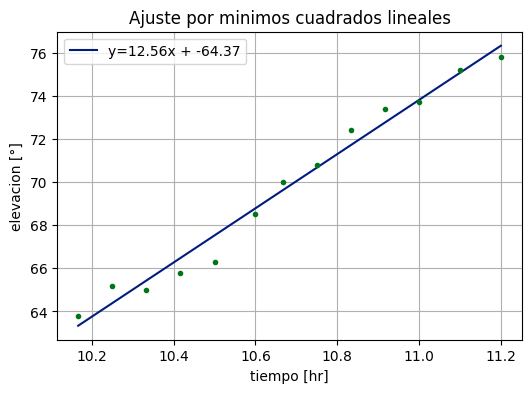

In [ ]:
# ajuste minimos cuadrados lineales
ts = np.linspace(min(df['time_hours']), max(df['time_hours']), 50)
ajs = linear_model(ts, params[0], params[1])

# grafica
fig = plt.figure(figsize=(6,4))
plt.title('Ajuste por minimos cuadrados lineales')
plt.plot(ts, ajs, label=f'y={params[0]:.2f}x + {params[1]:.2f}')
plt.plot(df['time_hours'], df['angle'], '.')
plt.xlabel('tiempo [hr]')
plt.ylabel('elevacion [°]')
plt.legend()
plt.grid()
plt.show()

Figura 1. Datos de elevación angular del sol en función del tiempo y ajuste por mínimos cuadrados lineales. para el archivo 2.
<br>

Así, el estimado de la velocidad angular aparente del sol es de $a=12.56$ [°/hr], para el documento 2. De ahora en adelante esto se dejará implicito en la pendiente de la ecuación de ajuste dentro de las graficas. Mientras que su error estándar asociado a la estimación de los parámetros es: $ s_{\hat{a}} = \sqrt{\text{diag}(\text{cov})}[0] = 0.556$. La cual considera la cantidad de datos utilizada en el ajuste, Por lo tanto, en este caso no es necesario dividir por la raíz del numero de datos al evaluar un estadístico, como se verá a continuación





### **b) prueba de hipótesis velocidad angular media**

Estableciendo las hipótesis nula tal que la velocidad angular media aparente del sol sobre la esfera celeste es dada únicamente por el movimiento diurno, es decir que tiene un valor de $360/24$ [°/hr] $=  15$  [°/hr], ignorando la influencia del movimiento traslacional debido a su poca significancia respecto al diurno en el intervalo de tiempo de $1$ hora. La hipótesis alternativa se estableció con la negación simétrica de este valor. <br>

$H_0$: $\mu = 15$  [°/hr] <br>
$H_a$: $\mu \neq 15$  [°/hr]<br>

Estableciendo un nivel de confianza del $95$% pues es uno de los mas comúnmente usados, y en consecuencia un nivel de significancia $α=0.05$

En principio se podría asumir que el estimador $\hat{a}$ de la velocidad angular media sigue una distribución normal debido al Teorema del Límite Central (TLC), junto a las suposiciones base del modelo de regresión lineal; que son linealidad, que los errores son independientes y normalmente distribuidos, y que si la muestra es suficientemente grande, entonces el estimador sigue una distribución normal. (Jay L. Devore, cap 12, 2010). Además como no se conoce la desviación estándar $σ$ poblacional, entonces se debe usar su estimación $S$, lo que conduce a elegir el estadístico t.

Con el nivel de significancia $α=0.05$ establecido y los grados de libertad $ν = n_{\text{datos}}-n_{\text{params(a,b)}} = 13-2 = 11$, se encuentran los valores t-críticos usando las tablas del libro Jay L. Devore, donde $t_{critic}=±2.201$. Con estos valores críticos se establecen las zonas de rechazo y aceptación, con lo que se puede evaluar el estadístico.<br>

**Estadístico t-student:**

$$t = \frac{\hat{a}-\mu}{s/ \sqrt{n}}$$

donde:
- $\hat{a}$ es la media de la muestra.
- $\mu=15$ [°/hr] es la media poblacional teórica.
- $s$ es la desviación estándar de la muestra.
- $n$ es el tamaño de la muestra.

Evaluando los datos:

$$t = \frac{\hat{a}-\mu}{s_{\hat{a}}} = -4.388$$

Finalmente se observa que el valor del estadistico cae por fuera de la zona de aceptacion $t < -t_{\text{critic}}$, de modo que se debe rechazar la hipotesis nula, y en consecuencia la velocidad media obtenida del estadistico $\hat{a}$ sobre los datos del archivo 2, no representa una realizacion estocastica de este fenomeno.  




In [ ]:
# error estandar
std_err = np.sqrt(np.diag(cov))[0]
known_mean = 15 # media real


# 2. nivel de significancia
CL = 0.95
alpha = 1-CL
nu = len(df) - 2  # Grados de libertad (número de puntos - número de parámetros ajustados)

# t critico
t_critic = stats.t.ppf(1 - alpha/2, nu)

# 3. Calcular el valor t
t_value = (np.abs(params[0]) - known_mean) / std_err


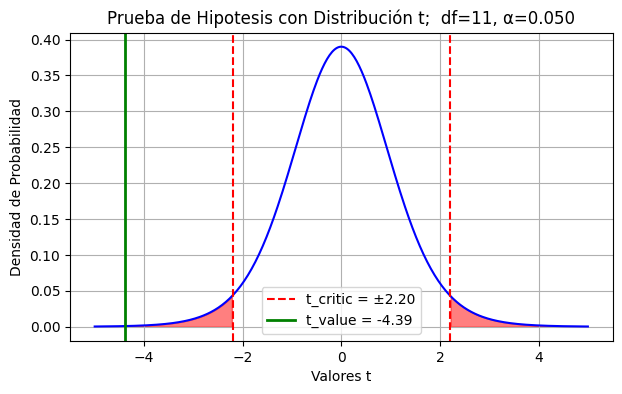

In [ ]:
# Rango para la distribución t
x = np.linspace(-5, 5, 400)
y = stats.t.pdf(x, nu)


# gráfica
plt.figure(figsize=(7,4))

plt.plot(x, y, 'b-')
# áreas de rechazo
plt.fill_between(x, 0, y, where=(x<=-t_critic), color='red', alpha=0.5)
plt.fill_between(x, 0, y, where=(x>=t_critic), color='red', alpha=0.5)
# valores críticos t
plt.axvline(-t_critic, color='r', linestyle='--', label=f't_critic = ±{t_critic:.2f}')
plt.axvline(t_critic, color='r', linestyle='--')
# valor del estadístico t
plt.axvline(t_value, color='g', linestyle='-', linewidth=2, label=f't_value = {t_value:.2f}')


plt.title(f'Prueba de Hipotesis con Distribución t;  df={nu}, α={alpha:.3f}')
plt.ylabel('Densidad de Probabilidad')
plt.xlabel('Valores t')
plt.legend()
plt.grid()
plt.show()

Figura 2. Distribución t, con zonas de rechazo y aceptación con evaluación del estadístico t para la hipótesis nula $H_o$ para el archivo 2.
<br>

Hay que notar que el valor encontrado por el estadístico cae en la zona de rechazo izquierda, por lo que está subestimando el valor real de la velocidad angular media.



___

## **Parte 2**

___


### **a). Estimación de la velocidad solar media para todos los archivos**

Algunos de los datos tenían leves errores como: En el archivo 0 y 1 el dato de la línea 13 (hora de medida 15:13) no parece concordar con el resto; la medida anterior se da a las 17:08, y ambas tienen el mismo ángulo asociado 16°. y tampoco parece tener sentido con la siguiente medida en la línea 14 que es a las 16:13 y a un ángulo mucho mayor; por lo que se decidió reemplazar la hora 15:13 por 17:13. periódicamente en los archivos que poseían este error. Además, los archivos eran copias por pares; los archivos 0 y 1 eran los mismos, igual que 2 y 3, y así sucesivamente.

Para la estimación de la velocidad angular media se repitió el proceso de ajuste de la parte 1 para cada uno de los archivos.



In [ ]:
# numero de files en carpeta
n_files = !ls datos | wc -l
n_files = int(n_files[0])

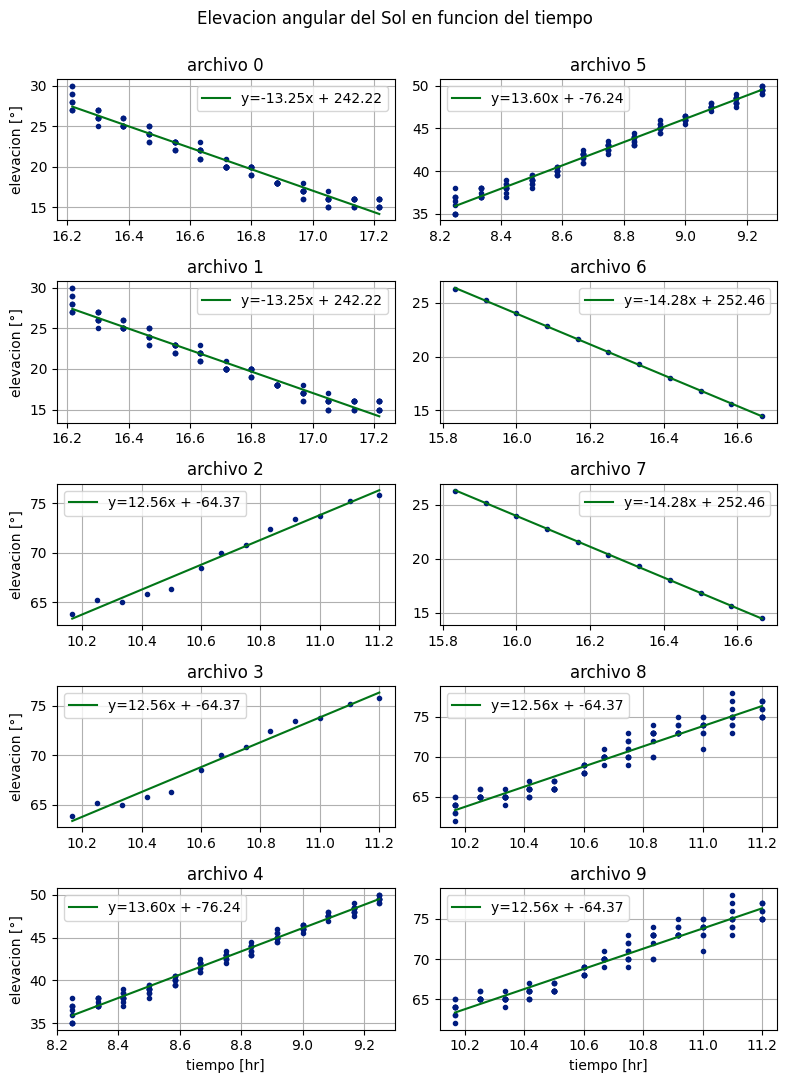

In [ ]:
fig, ax = plt.subplots(int(n_files/2),2, figsize=(8,11))
fig.suptitle('Elevacion angular del Sol en funcion del tiempo\n')
vels_ang = []
std_errs = []
k = 0; j = 0


for i in range(n_files): # cada archivo

  # ruta
  file_i = f'datos/{i}_angulos_solares.txt'

  # datos
  df_i = pd.read_csv(file_i, header=None, names=encabezado, sep='\s+')

  # convertir tiempo a horas
  df_i['timez'] = pd.to_datetime(df_i['time'], format='%H:%M')
  df_i['time_hours'] = df_i['timez'].dt.hour + df_i['timez'].dt.minute / 60

  # ajuste lineal
  param_i, cov_i = curve_fit(linear_model, df_i['time_hours'], df_i['angle'])
  ts = np.linspace(min(df_i['time_hours']), max(df_i['time_hours']), 50)

  std_errs.append( np.sqrt(np.diag(cov_i))[0] )
  vels_ang.append( np.abs(param_i[0]) )


  # grafica del angulo vs tiempo
  ax[j,k].set_title(f'archivo {i}')
  ax[j,k].plot(df_i['time_hours'], df_i['angle'], '.')
  ax[j,k].plot(ts, linear_model(ts, param_i[0], param_i[1]), label=f'y={param_i[0]:.2f}x + {param_i[1]:.2f}')
  ax[j,k].legend()
  ax[j,k].grid()

  j += 1
  if i == 4: k=1; j=0

vels_ang = np.array(vels_ang)
std_errs = np.array(std_errs)

for j in range(5):
  ax[j,0].set_ylabel('elevacion [°]')
ax[4,0].set_xlabel('tiempo [hr]')
ax[4,1].set_xlabel('tiempo [hr]')
plt.tight_layout()
plt.show()

Figura 3. Datos elevación angular vs tiempo de todos los archivos con su respectivo ajuste lineal, y ajuste de la velocidad angular como la pendiente.

Note que como algunos datos fueron tomados en la mañana y en la tarde eso hace que la pendiente sea positiva y negativa dependiendo de la hora. Entonces para un adecuado tratamiento de cada una de los valores de velocidad angular media se tomará el valor absoluto de las pendientes. En general se observa que la mayoría de los datos concuerdan en el intervalo de medición con un ajuste lineal.




### **b) Distribución de las medias**

Usar un histograma para representar tan pocos datos y como además se repite no aporta mucha información. No obstante, las características de una distribución cualquiera que provee el Skewness y la Curtosis pueden ser útiles, por lo que
usando la clase `scipy.stats` se evaluó un arreglo con los valores de las medias encontradas anteriormente en las funciones `skew` y `kurtosis` resultando en:

* Asimetría (Skewness): 0.351
* Curtosis: -1.244

Es decir que la posible distribución que siguen las medias es una es casi simétrica con una ligera asimetría positiva, lo que quiere decir que tiene una cola derecha ligeramente más pesada. Con curtosis platicúrtica, lo que implica colas más ligeras, un pico más ancho y menos pronunciado que una distribución normal.









In [ ]:
asimetria = stats.skew(vels_ang)
curtosis = stats.kurtosis(vels_ang)


print(f"Asimetría (Skewness): {asimetria}")
print(f"Curtosis: {curtosis}")


Asimetría (Skewness): 0.3512967707948951
Curtosis: -1.243768083721685


### **c). Media de las velocidades medias**

Para simplificar escritura, se denotó como $\bar{ω}$ a la media de las velocidades angulares medias ($a_i$), luego usando el estimador de la media:


$$ \bar{\omega} = \frac{1}{n} \sum_{i=1}^{n} a_i = 13.249$$




In [ ]:
media_medias = np.mean(vels_ang)

desv_try = (sum((vels_ang-known_mean)**2)/(n_files-1))**.5

media_medias, desv_try

(13.248858257182519, 1.9698478939976654)

**Comportamiento de la media de las medias respecto al valor real**<br>

Repitiendo la prueba de hipótesis del punto (1,b) con las mismas hipótesis, nivel de significancia, y estadístico t, con un cambio en los grados de libertad $ν=n_{\text{datos}}-1=10-1=9$, de modo que los t-criticos $= ±2.26$. Pero esta vez adecuada a los valores de la media de las medias $\bar{ω}$, y su error estándar normal, el cual se encontró usando el estimador:

$$ s^2 = \frac{1}{n - 1} \sum_{i=1}^{n} (a_i - μ)^2 $$

$$ s = 1.970 $$

Donde $n$ es el número de archivos. Con lo cual el estadístico t queda en este caso: $$t = \frac{\hat{a}-\mu}{s/ \sqrt{n}}=-2.81$$





In [ ]:
# 2. nivel de significancia
CL = 0.95
alpha = 1-CL
nu = n_files - 1  # Grados de libertad

# t critico
t_critic = stats.t.ppf(1 - alpha/2, nu)

# 3. Calcular el valor t
t_value = (media_medias - known_mean) / (desv_try/np.sqrt(n_files))


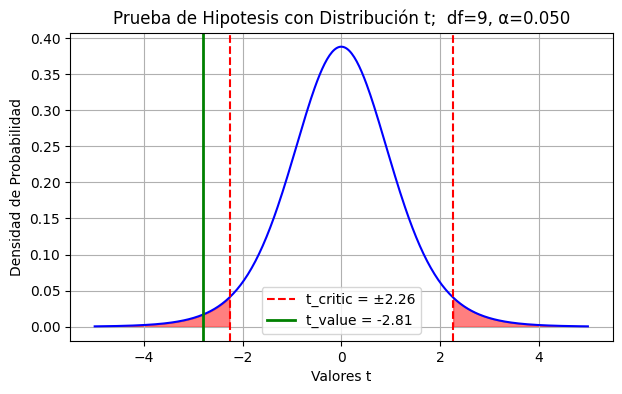

In [ ]:
# Rango para la distribución t
x = np.linspace(-5, 5, 400)
y = stats.t.pdf(x, nu)

# gráfica
plt.figure(figsize=(7,4))

plt.plot(x, y, 'b-')
# áreas de rechazo
plt.fill_between(x, 0, y, where=(x<=-t_critic), color='red', alpha=0.5)
plt.fill_between(x, 0, y, where=(x>=t_critic), color='red', alpha=0.5)
# valores críticos t
plt.axvline(-t_critic, color='r', linestyle='--', label=f't_critic = ±{t_critic:.2f}')
plt.axvline(t_critic, color='r', linestyle='--')
# valor del estadístico t
plt.axvline(t_value, color='g', linestyle='-', linewidth=2, label=f't_value = {t_value:.2f}')


plt.title(f'Prueba de Hipotesis con Distribución t;  df={nu}, α={alpha:.3f}')
plt.ylabel('Densidad de Probabilidad')
plt.xlabel('Valores t')
plt.legend()
plt.grid()
plt.show()

Figura 4. Distribución t, con zonas de rechazo y aceptación con evaluación del estadístico t para la hipótesis nula $H_o$ para la media de las medias.
<br>

Se observa que la evaluación del estadístico t para la media de las medias a pesar de que hubo una mejoría, pues se redujo el valor absoluto del estadístico. Este sigue cayendo en la zona de rechazo. De modo que a pesar de que se acerque al valor teórico de $μ=15$[°/hr], se debe rechazar nuevamente la hipótesis nula.

Una posible razón por la cual en ambos intentos se deba rechazar la hipótesis de que la velocidad angular media del sol sobre la esfera celeste es igual a $15$ [°/hr] es porque todos los datos tomados en los archivos están subestimando el valor teórico, como se muestra en la tendencia del estadístico a caer en la zona de rechazo izquierda en ambos casos, es decir que en la medición de tales datos hubo un sesgo en la medición real de la velocidad angular media del sol. Lo que puede explicarse si los datos de los ángulos solo reportaron la componente vertical del ángulo que se desplazó el sol en cada instante de tiempo, pues debido a la trayectoria aparente cambiante del sol a lo largo del año, esta suele tener componente vertical y horizontal, que solo en $24$ días del año pasa por el zenit, día en el cual si se podría tomar únicamente la componente vertical del cambio del ángulo. No obstante, al solo darse en $2$ días de $365.25$, es muy probable que los datos no se midieran en estos $2$ particulares días, sino en otro momento donde la trayectoria aparente esta "inclinada", lo que causaría la subestimación de la velocidad media del sol.




### **d). Distribución de los errores**

Definidos como la diferencia entre la velocidad media y la media de las medias, por razones similares a las del punto (2,b), para dar con las características de la distribución se calcularon los mismos momentos:

* Asimetría (Skewness): 0.351
* Curtosis: -1.244

Que en esencia son los mismos valores obtenidos para la distribución de las velocidades medias del punto (2,b), pues hay que observar que esta definición del error solo está haciendo una translación de la distribución de las velocidades medias un valor $\bar{ω}$, y este tipo de desplazamientos no afecta la asimetría ni la curtosis. Por lo que en principio no se podría concluir que es una distribución normal estrictamente.  




In [ ]:
err = vels_ang - np.mean(media_medias)
err

asimetria = stats.skew(err )
curtosis = stats.kurtosis(err )

print(f"Asimetría (Skewness): {asimetria}")
print(f"Curtosis: {curtosis}")

Asimetría (Skewness): 0.351296770794892
Curtosis: -1.2437680837216873


___

## **Parte 3**

___


### **a) Intervalos de confianza para la media de las medias**

Estimación de intervalos de confianza con $69\%, 90\%, 99\%$ CL para la distribución t con grados de libertad $ν = n_{\text{files}} - 1 = 9$ para la media de las velocidades medias. Usando la fórmula para la estimación tamaño de los intervalos de confianza para una distribución normal, con la aproximación de la desviación estándar poblacional con la muestral, que subyace a la distribución t.

$$L = 2 \ t_{\text{critic}} \ S / \sqrt{n}$$

Se encuentra que los intervalos dados por:

$$\text{Ic} = [ \ \bar{ω}-L/2, \ \ \bar{ω}+L/2 \ ]$$

Evaluando se obtiene:

* $\text{Cl} = 0.69$, $t_{c} = 1.076, \quad$ $\text{Ic} = [12.579, 13.919]$

* $\text{Cl} = 0.90$, $t_{c} = 1.833, \quad$ $\text{Ic} = [12.107, 14.391]$

* $\text{Cl} = 0.99$,  $t_{c} = 3.250, \quad$ $\text{Ic} = [11.224, 15.273]$



In [ ]:
nu = n_files - 1  # Grados de libertad 9

for CL_i in [0.69, 0.90, 0.99]:

  alpha_i = 1-CL_i

  t_critic_i = stats.t.ppf(1 - alpha_i/2, nu)

  L_i = 2*t_critic_i* (desv_try/np.sqrt(n_files))

  I_i = np.array([media_medias-L_i/2, media_medias+L_i/2])

  print(CL_i, t_critic_i, I_i)

0.69 1.0758208879382214 [12.57870727 13.91900925]
0.9 1.8331129326536335 [12.10697445 14.39074206]
0.99 3.2498355415921254 [11.22446876 15.27324776]


### b) Interpretación de los Intervalos de confianza

Lo primero a notar es que se podría esperar, que a medida que se aumenta el nivel de confianza, el intervalo de confianza se hace más grande, y consecuentemente aumentando la dispersión, de modo que la precisión del intervalo disminuye, silogismo que se menciona en el libro (Jay L. Devore).

Además, cada nivel de significancia, por ejemplo, el de 0.99, implica que
si se repite el experimento muchas veces, aproximadamente el 99% de las veces, el valor real de la media se encontrará dentro de tal intervalo. Del mismo modo para los demás valores. También se puede evidenciar el leve sesgo a derecha, donde se encuentra el valor real, haciéndose cada vez más grande el lado derecho de los intervalos.

